# 🌍 Air Quality Index (AQI) Prediction System

## Project Overview

Air pollution is one of the major environmental challenges affecting human health and quality of life. The objective of this project is to analyze air quality data from Indian cities and build a machine learning model capable of predicting the Air Quality Index (AQI) based on pollutant concentrations.

The project includes:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Building
- Model Evaluation
- Model Deployment using Streamlit

## 📚 Import Required Libraries 

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 📂 Dataset Loading

In [3]:
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Documents\AQI_ml-project\dataset\city_day.csv")

## 🔍 Initial Data Exploration

In [4]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [5]:
df.shape

(29531, 16)

In [6]:
df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [8]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


## 🧹 Missing Value Analysis

In [9]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

## 🛠 Data Cleaning

In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col].fillna(df[col].median(), inplace=True)

In [11]:
df['AQI_Bucket'].fillna(
    df['AQI_Bucket'].mode()[0],
    inplace=True
)

In [12]:
df.isnull().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df['Date'] = pd.to_datetime(df['Date'])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        29531 non-null  object        
 1   Date        29531 non-null  datetime64[ns]
 2   PM2.5       29531 non-null  float64       
 3   PM10        29531 non-null  float64       
 4   NO          29531 non-null  float64       
 5   NO2         29531 non-null  float64       
 6   NOx         29531 non-null  float64       
 7   NH3         29531 non-null  float64       
 8   CO          29531 non-null  float64       
 9   SO2         29531 non-null  float64       
 10  O3          29531 non-null  float64       
 11  Benzene     29531 non-null  float64       
 12  Toluene     29531 non-null  float64       
 13  Xylene      29531 non-null  float64       
 14  AQI         29531 non-null  float64       
 15  AQI_Bucket  29531 non-null  object        
dtypes: datetime64[ns](1), 

## 📅 Feature Engineering

In [17]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['City'] = le.fit_transform(df['City'])

## 📊 AQI Distribution Analysis

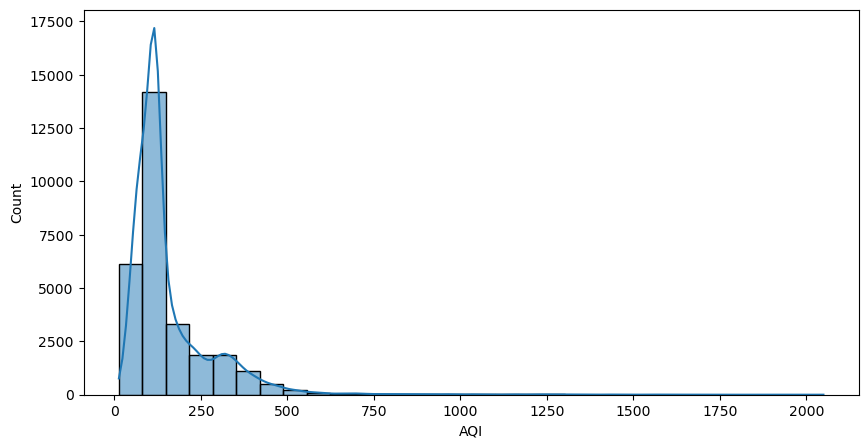

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(df['AQI'], bins=30, kde=True)

plt.show()

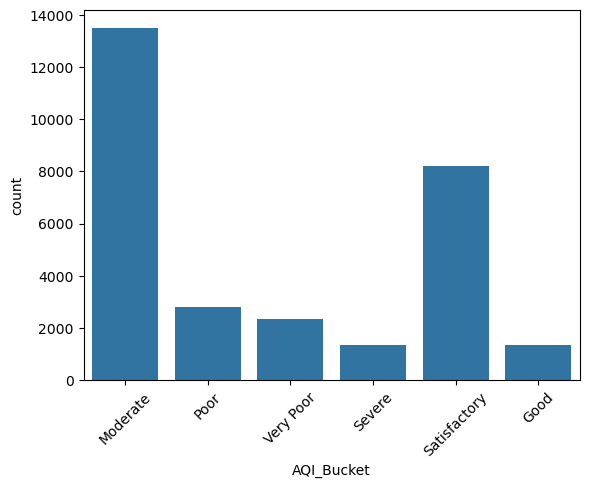

In [20]:
sns.countplot(x='AQI_Bucket', data=df)

plt.xticks(rotation=45)

plt.show()

## 🔥 Correlation Analysis

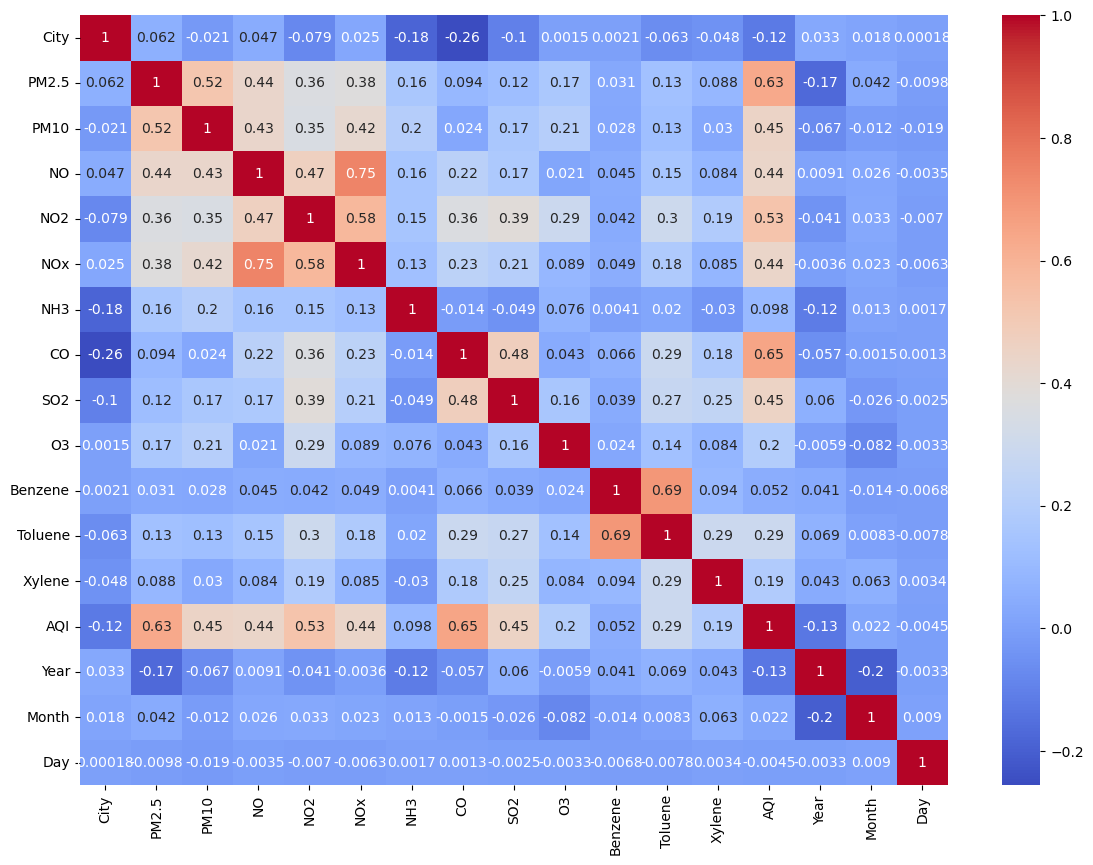

In [21]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [22]:
X = df.drop(
    ['AQI','AQI_Bucket','Date'],
    axis=1
)

y = df['AQI']

In [23]:
X.shape

(29531, 16)

In [24]:
y.shape

(29531,)

## ✂ Data Splitting : Training Model

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 🤖 Machine Learning Model Development

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [34]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train,y_train)

xgb_pred = xgb.predict(X_test)

In [68]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head())

   Feature  Importance
7       CO    0.373294
1    PM2.5    0.314384
13    Year    0.079096
2     PM10    0.061950
3       NO    0.037905


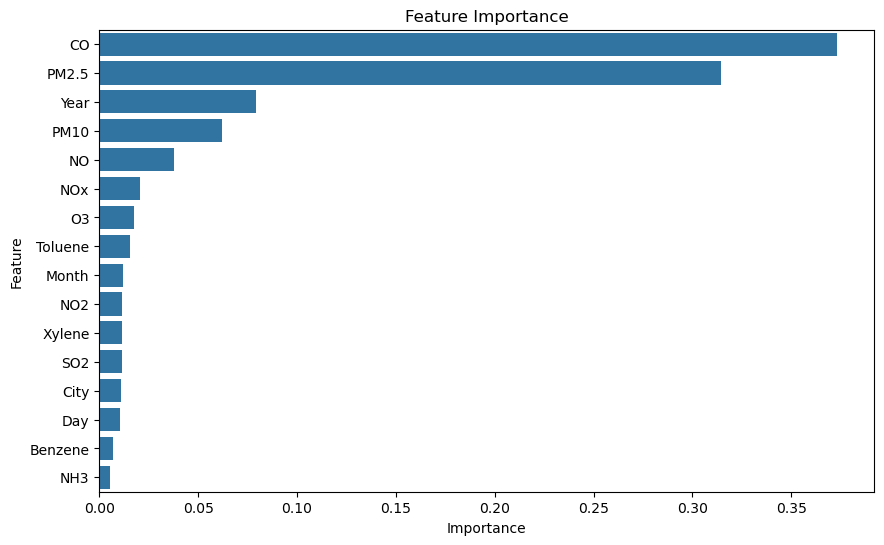

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')
plt.show()

In [70]:
importance.to_csv(
    '../model/feature_importance.csv',
    index=False
)

print("Feature Importance Saved Successfully")

Feature Importance Saved Successfully


## 📊 Model Performance Comparison

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate(y_true,y_pred):

    mae = mean_absolute_error(y_true,y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true,y_pred)
    )

    r2 = r2_score(y_true,y_pred)

    print("MAE:",mae)
    print("RMSE:",rmse)
    print("R2:",r2)

In [77]:
print(' Linear Regression')
evaluate(y_test, lr_pred)
print('-------------------------------------------------------------------')
print(' XGBRegressor')
evaluate(y_test, xgb_pred)

 Linear Regression
MAE: 29.742428705621574
RMSE: 54.42071424319151
R2: 0.807618219881648
-------------------------------------------------------------------
 XGBRegressor
MAE: 19.93675127089155
RMSE: 41.962187281141716
R2: 0.8856195766356902


## ⭐ Feature Importance Analysis

In [37]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':xgb.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

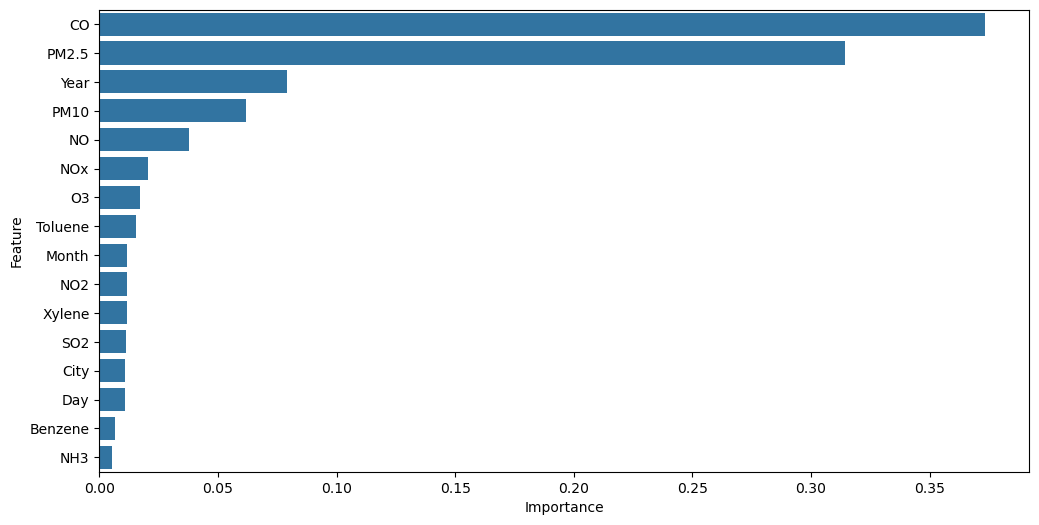

In [38]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.show()

## 💾 Model Persistence

Save trained model artifacts for deployment.

### Files Saved
- aqi_model.pkl
- city_encoder.pkl
- feature_importance.csv
- correlation.csv

Avoids retraining the model every time predictions are required.

In [44]:
from joblib import dump

dump(xgb, '../model/aqi_model.pkl')


['../model/aqi_model.pkl']

In [49]:
dump(
    le,
    '../model/city_encoder.pkl'
)

['../model/city_encoder.pkl']

In [52]:
import joblib

model = joblib.load(
    '../model/aqi_model.pkl'
)

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['City'] = le.fit_transform(df['City'])

In [53]:
prediction = model.predict(X_test)

In [54]:
print(prediction)

[118.69384  117.768585 136.0751   ... 111.28847   68.487564 140.0225  ]


In [56]:
encoder = joblib.load(
    '../model/city_encoder.pkl'
)

In [58]:
print(type(encoder))
print(encoder.classes_[:10])

<class 'sklearn.preprocessing._label.LabelEncoder'>
[0 1 2 3 4 5 6 7 8 9]


In [59]:
print(encoder.classes_)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


In [61]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Documents\AQI_ml-project\dataset\city_day.csv")

le = LabelEncoder()

le.fit(df['City'])

LabelEncoder()

In [62]:
le.transform(['Delhi'])

array([10])

In [64]:
import joblib

joblib.dump(
    le,
    '../model/city_encoder.pkl'
)

['../model/city_encoder.pkl']

In [65]:
print("Delhi Code:", le.transform(['Delhi']))
print("City Names:", le.classes_[:10])

Delhi Code: [10]
City Names: ['Ahmedabad' 'Aizawl' 'Amaravati' 'Amritsar' 'Bengaluru' 'Bhopal'
 'Brajrajnagar' 'Chandigarh' 'Chennai' 'Coimbatore']


In [72]:
corr = df.corr(numeric_only=True)

corr.to_csv(
    '../model/correlation.csv'
)

# ✅ Project Conclusion

## Summary

This project successfully developed a machine learning-based AQI prediction system using environmental pollutant data.

## Key Achievements

- Performed comprehensive data cleaning and preprocessing.
- Conducted exploratory data analysis.
- Engineered meaningful features.
- Compared multiple machine learning models.
- Selected XGBoost as the final model.
- Built an interactive Streamlit dashboard for deployment.

## Future Scope

- Real-time AQI prediction using APIs.
- Weather parameter integration.
- AQI forecasting for future dates.
- Cloud deployment and monitoring.